In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/chest_xray'

if not os.path.exists(extract_path):
    print("Unzipping dataset... this may take a minute.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Done unzipping!")
else:
    print("Dataset already unzipped. Skipping.")

Unzipping dataset... this may take a minute.
Done unzipping!


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
DATA_DIR = '/content/chest_xray/chest_xray/'

In [7]:
BATCH_SIZE=32
EPOCHS=15
LEARNING_RATE=0.001

In [8]:
# Transformation of images (MobileNetV2 needs 224*224)
# train_transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),      # Rotate slightly
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Zoom in/out
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [9]:
val_test_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [10]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_test_transform)

In [11]:
#Dataloaders break the dataset into batches and shuffle training data
train_loader= torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [12]:
print(f"Training images  : {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images  : {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training images  : 5216
Validation images: 16
Test images  : 624
Classes: ['NORMAL', 'PNEUMONIA']


In [13]:
# Loading the Pretrained Mobilenetv2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 138MB/s]


In [14]:
# Freeze all the base layers (feature extractor) of MobileNetV2
# for param in model.features.parameters():
#     param.requires_grad = False
# Only freeze the first 100 layers, let the rest learn
for i, param in enumerate(model.features.parameters()):
    if i < 100:
        param.requires_grad = False
    else:
        param.requires_grad = True


In [15]:
# replacing the final classification layer (original is 1000 classes) with 2 classes (normal and pneumonia)
num_features= model.classifier[1].in_features # original inputs from the pretrained model but I have changed it to provide only two output classes
model.classifier[1] = nn.Linear(num_features, 2)

In [16]:
model = model.to(device)

In [17]:
criterion = nn.CrossEntropyLoss()
# Optimizer take the gradient and update weights in backpropagation
# optimizer = optim.SGD(model.classifier.parameters(), lr=LEARNING_RATE, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Use a smaller LR for fine-tuning


In [18]:
# Cosine Annealing Scheduler gently drops the learning rate following a cosine curve
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [19]:
# Inside training loop
  # For each epoch -1) Train on training data ( weights are updated)
  #                 2) Validate on validation data(weights are not updated)

In [20]:
train_losses=[]
val_losses=[]

In [21]:
for epoch in range(EPOCHS):
  print(f"\n---Epoch {epoch+1} / {EPOCHS}---")

  model.train()
  running_trainin_loss=0.0

  for images , labels in train_loader:
      images = images.to(device)   # Move images to GPU
      labels = labels.to(device)   # Move labels to GPU

      optimizer.zero_grad() # for clearing old gradients
      outputs =model(images) #forward pass
      loss =criterion(outputs,labels) #calculating training loss
      loss.backward() # backpropagation of calculated gradient
      optimizer.step() #updating the weights

      running_trainin_loss+=loss.item()

  avg_train_loss=running_trainin_loss/len(train_loader)
  train_losses.append(avg_train_loss)
  print(f"Training Loss: {avg_train_loss:.4f}")

  #Validation Phase
  model.eval()
  running_val_loss=0.0
  correct=0
  total=0

  with torch.no_grad(): # we dont need gradient calculation here so disabling it
     for images, labels in test_loader: # I am changing to validate on test set
         images = images.to(device)
         labels = labels.to(device)

         outputs=model(images)
         loss=criterion(outputs,labels)
         running_val_loss+=loss.item()

         _,predicted=torch.max(outputs.data,1)
         total+=labels.size(0)
         correct+=(predicted==labels).sum().item()

  avg_val_loss=running_val_loss/len(test_loader)
  val_losses.append(avg_val_loss)
  accuracy=100*correct/total
  print(f"Training Loss: {avg_train_loss:.4f}")
  print(f"Validation Loss: {avg_val_loss:.4f}")
  print(f"Validation Accuracy: {accuracy:.2f}%")

# Step the scheduler at the end of each epoch to update the learning rate
  scheduler.step()
  print(f"Current LR: {scheduler.get_last_lr()}")



---Epoch 1 / 15---
Training Loss: 0.2463
Training Loss: 0.2463
Validation Loss: 0.2247
Validation Accuracy: 91.03%
Current LR: [9.890738003669029e-05]

---Epoch 2 / 15---
Training Loss: 0.1144
Training Loss: 0.1144
Validation Loss: 0.1922
Validation Accuracy: 92.31%
Current LR: [9.567727288213005e-05]

---Epoch 3 / 15---
Training Loss: 0.0928
Training Loss: 0.0928
Validation Loss: 0.1732
Validation Accuracy: 93.91%
Current LR: [9.045084971874738e-05]

---Epoch 4 / 15---
Training Loss: 0.0758
Training Loss: 0.0758
Validation Loss: 0.1813
Validation Accuracy: 93.43%
Current LR: [8.345653031794292e-05]

---Epoch 5 / 15---
Training Loss: 0.0663
Training Loss: 0.0663
Validation Loss: 0.1901
Validation Accuracy: 92.15%
Current LR: [7.500000000000001e-05]

---Epoch 6 / 15---
Training Loss: 0.0648
Training Loss: 0.0648
Validation Loss: 0.1855
Validation Accuracy: 92.15%
Current LR: [6.545084971874738e-05]

---Epoch 7 / 15---
Training Loss: 0.0579
Training Loss: 0.0579
Validation Loss: 0.1749


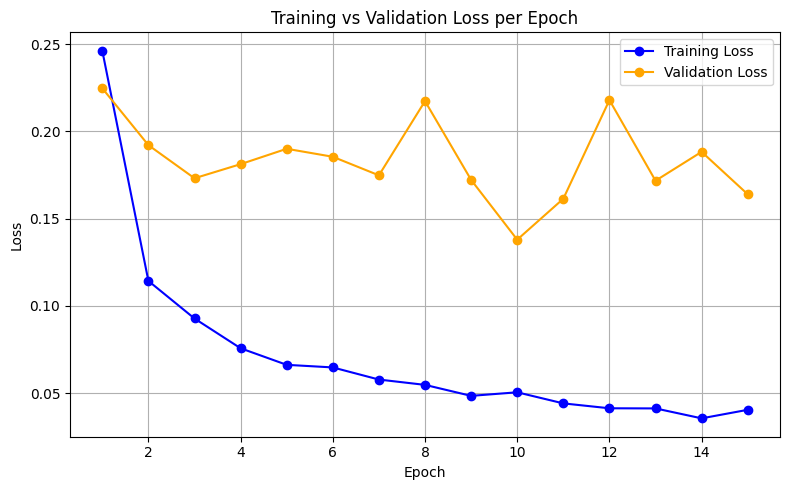

Plot saved as loss_plot.png


In [23]:
# Plotting the Training Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss',   marker='o', color='blue')
plt.plot(range(1, EPOCHS + 1), val_losses,   label='Validation Loss', marker='o', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_plot.png')
plt.show()
print("Plot saved as loss_plot.png")


In [ ]:
# Final test on the Test Dataset

print("----Final test on the Test Dataset----")
model.eval()
correct=0
total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    outputs=model(images)
    _,predicted=torch.max(outputs.data,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()

  print('Accuracy of the network on the test images: {} %'.format(100*correct /total))

In [ ]:
#Saving the trained model
torch.save(model.state_dict(), 'mobilenetv2_pneumonia.pth')
print("Model saved as mobilenetv2_pneumonia.pth")
